---
date: '2026-03-12T20:00:07+08:00'
title: 'Using Pandas For Getting Data And Analise Them'
feature_link: "https://www.midjourney.com/home/"
feature_text: "by IA Midjourney"
description: 'Using Pandas For Getting Data And Analise Them'
isStarred: false
tags:
- pandas
categories:
- dev
images:
keywords:
series:
- Data and Data Tools
---

## The idea

I want to test some of the pandas functionality so I try the import from HTML table for make some data analisys.
So I choose a web page with data in a table (or two in this case) about manga.

In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
from bs4 import BeautifulSoup
import re

Here we have the basic import for the needed package for the project.

In [2]:
url = "https://www.mangacodex.com/oricon_yearly.php?title_series=&year_series=All&title_volumes=&year_volumes=All"

pd.set_option("display.precision", 0)
pd.options.display.float_format = '{:.2f}'.format

Some basic config (the log, the url,...) for my little script. I allwayse put at the top of the file for easy edit of them, if needed.

In [3]:
print("Downloading data from the page...")
tables = pd.read_html(url, thousands='.', decimal =',')
print(f"Found {len(tables)} tables on the page.")

df1 = pd.DataFrame(tables[0])
print(type(df1))
df2 = pd.DataFrame(tables[1])
print(type(df2))

Found 2 tables on the page.
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


Starting with the scrape of the page with Pandas. In this case it returnes 2 table in pandas.DataFrame

In [4]:
if len(tables) >= 2:
    table_series = tables[1]
    table_volumes = tables[0]

else:
    print("Error: The page does not contain enough tables.")
    raise Error

And now we have the two table as pandas Dataframe. Are there some empty data?

In [5]:
print("-*-" * 20)
print("Missing value stats for Series:")
print(table_series.isnull().sum())
print()
print("-*-" * 20)
print("Missing value stats for Volumes:")
print(table_volumes.isnull().sum())

-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Missing value stats for Series:
Ranking    0
Volume     0
Sales      0
Year       0
dtype: int64

-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Missing value stats for Volumes:
Ranking    0
Title      0
Sales      0
Year       0
dtype: int64


So we know the data is consistant so we need to know some generic data about this two dataset.

In [6]:
print("-*-")
print(table_series.head())
print()
print("-*-")
print(table_volumes.head())


-*-
   Ranking             Volume    Sales  Year
0        1          One Piece  5956540  2008
1        2             Naruto  4261054  2008
2        3  20th Century Boys  3710054  2008
3        4     Hitman Reborn!  3371618  2008
4        5             Bleach  3161825  2008

-*-
   Ranking          Title    Sales  Year
0        1  One Piece #50  1678208  2008
1        2  One Piece #51  1646978  2008
2        3       Nana #19  1645128  2008
3        4  One Piece #49  1544000  2008
4        5       Nana #20  1431335  2008


Ok now I need to reformat data from table_volumes and check the output and set some column to int

In [7]:
table_volumes[['Volume', 'Volume_Number']] = table_volumes['Title'].str.split(' #', expand=True)

# Remove not number data
table_volumes['Volume_Number'] = table_volumes['Volume_Number'].astype(str).str.extract(r'(\d+)')[0]

table_volumes['Volume_Number'] = pd.to_numeric(table_volumes['Volume_Number'])
table_volumes['Sales'] = pd.to_numeric(table_volumes['Sales'])

print()
print("-*-")
print(table_volumes.head())


-*-
   Ranking          Title    Sales  Year     Volume  Volume_Number
0        1  One Piece #50  1678208  2008  One Piece          50.00
1        2  One Piece #51  1646978  2008  One Piece          51.00
2        3       Nana #19  1645128  2008       Nana          19.00
3        4  One Piece #49  1544000  2008  One Piece          49.00
4        5       Nana #20  1431335  2008       Nana          20.00


## Start the analysis

We start with all the selling data for year.

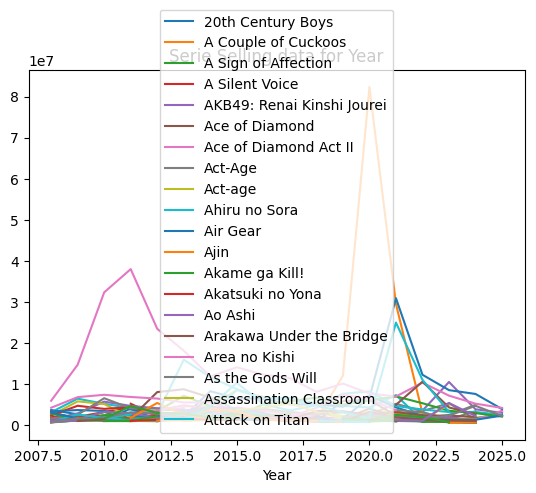

In [8]:
df_pivot = table_series.pivot(index='Year', columns='Volume', values='Sales')

ax = df_pivot.plot()

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:20], labels[:20])

plt.title('Serie Selling data for Year')
plt.show()

Ok we need to clean some of this caos of a plot.

* Remove the HUGE legend
* Having a plot type which is readable and usefull (an area plot?)
* Fix the X increment ( I want full year, not halfs)

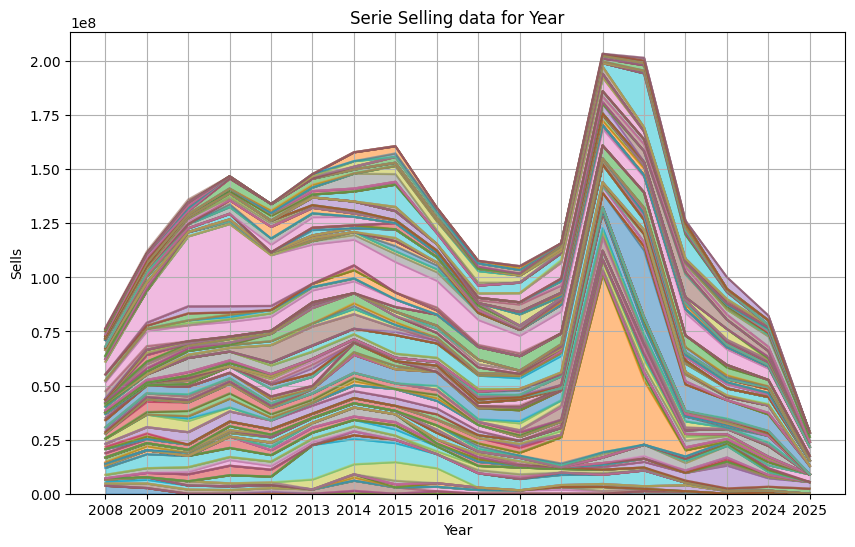

In [9]:
df_pivot = table_series.pivot(index='Year', columns='Volume', values='Sales')

# Remove the legend
ax = df_pivot.plot(kind='area', alpha=0.5, figsize=(10, 6), legend=False)

# Fix the year thinks
years = df_pivot.index.unique()
plt.xticks(np.arange(min(years), max(years) + 1, 1))

# Add some labels
plt.title('Serie Selling data for Year')
plt.xlabel('Year')
plt.ylabel('Sells')

plt.grid(True)
plt.show()

Ok now can we put some time reference for Japan?

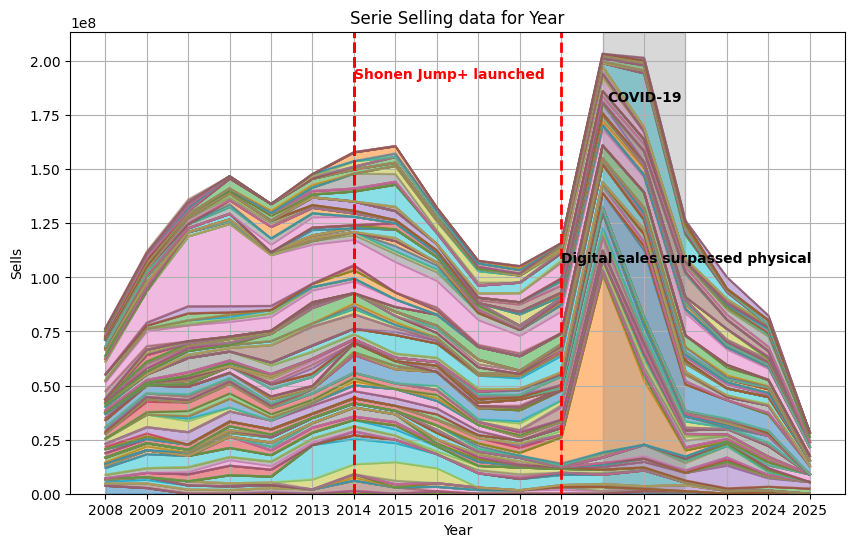

In [10]:
df_pivot = table_series.pivot(index='Year', columns='Volume', values='Sales')

ax = df_pivot.plot(kind='area', alpha=0.5, figsize=(10, 6), legend=False)
years = df_pivot.index.unique()
plt.xticks(np.arange(min(years), max(years) + 1, 1))

plt.title('Serie Selling data for Year')
plt.xlabel('Year')
plt.ylabel('Sells')
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)


# Marker for Shonen Jump+
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)
plt.text(2014, ax.get_ylim()[1]*0.9, 'Shonen Jump+ launched', color='red', fontweight='bold')

# Marker for digital manga sales have surpassed physical manga  source: https://hon.jp/news/1.0/0/30684
plt.axvline(x=2019, color='red', linestyle='--', linewidth=2)
plt.text(2019, ax.get_ylim()[1]*0.5, 'Digital sales surpassed physical', color='black', fontweight='bold')

# Gray area for the COVID-19 years with label
plt.axvspan(2020, 2022, color='gray', alpha=0.3)
plt.text(2021, ax.get_ylim()[1]*0.85, 'COVID-19', color='black', fontweight='bold', ha='center')

plt.grid(True)
plt.show()

Ok now we select some of the manga for having a better view. I put some of the biggest manga for comparison

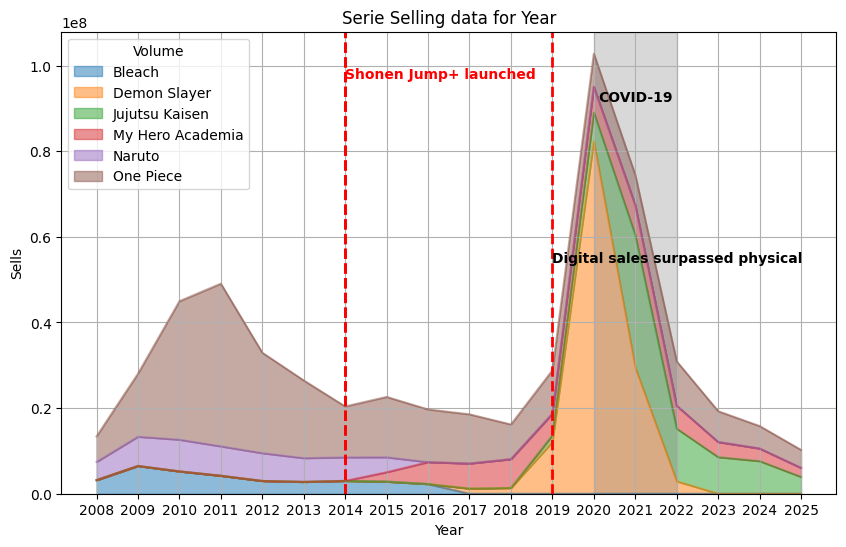

In [11]:
filter_series = ['One Piece', 'Naruto', 'Bleach', 'Demon Slayer','Jujutsu Kaisen','My Hero Academia']
filtered_table_series = table_series[table_series['Volume'].isin(filter_series)]
df_pivot = filtered_table_series.pivot(index='Year', columns='Volume', values='Sales')

ax = df_pivot.plot(kind='area', alpha=0.5, figsize=(10, 6))
years = df_pivot.index.unique()
plt.xticks(np.arange(min(years), max(years) + 1, 1))

plt.title('Serie Selling data for Year')
plt.xlabel('Year')
plt.ylabel('Sells')
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)


# Marker for Shonen Jump+
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)
plt.text(2014, ax.get_ylim()[1]*0.9, 'Shonen Jump+ launched', color='red', fontweight='bold')

# Marker for digital manga sales have surpassed physical manga  source: https://hon.jp/news/1.0/0/30684
plt.axvline(x=2019, color='red', linestyle='--', linewidth=2)
plt.text(2019, ax.get_ylim()[1]*0.5, 'Digital sales surpassed physical', color='black', fontweight='bold')

# Gray area for the COVID-19 years with label
plt.axvspan(2020, 2022, color='gray', alpha=0.3)
plt.text(2021, ax.get_ylim()[1]*0.85, 'COVID-19', color='black', fontweight='bold', ha='center')

plt.grid(True)
plt.show()

And if I want to have a good analysis for the second dataset I need to make a plot for one manga at the time (One Piece for example) with some label about this specifical manga

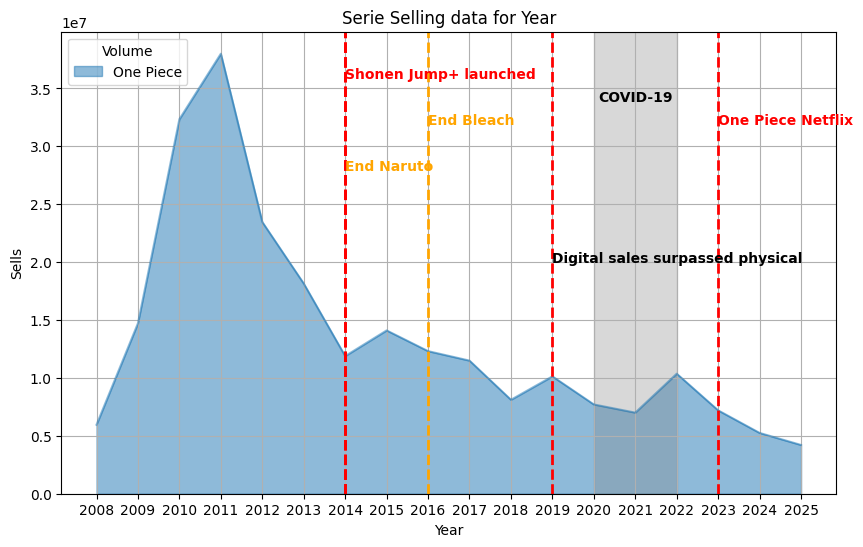

In [12]:
filter_series = ['One Piece']
filtered_table_series = table_series[table_series['Volume'].isin(filter_series)]
df_pivot = filtered_table_series.pivot(index='Year', columns='Volume', values='Sales')

ax = df_pivot.plot(kind='area', alpha=0.5, figsize=(10, 6))
years = df_pivot.index.unique()
plt.xticks(np.arange(min(years), max(years) + 1, 1))

plt.title('Serie Selling data for Year')
plt.xlabel('Year')
plt.ylabel('Sells')
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)


# Marker for Shonen Jump+
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)
plt.text(2014, ax.get_ylim()[1]*0.9, 'Shonen Jump+ launched', color='red', fontweight='bold')

# Marker for Bleach
plt.axvline(x=2016, color='orange', linestyle='--', linewidth=2)
plt.text(2016, ax.get_ylim()[1]*0.8, 'End Bleach', color='orange', fontweight='bold')

# Marker for Naruto
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)
plt.text(2014, ax.get_ylim()[1]*0.7, 'End Naruto', color='orange', fontweight='bold')

# Marker for digital manga sales have surpassed physical manga  source: https://hon.jp/news/1.0/0/30684
plt.axvline(x=2019, color='red', linestyle='--', linewidth=2)
plt.text(2019, ax.get_ylim()[1]*0.5, 'Digital sales surpassed physical', color='black', fontweight='bold')

# Marker for One Piece Netflix
plt.axvline(x=2023, color='red', linestyle='--', linewidth=2)
plt.text(2023, ax.get_ylim()[1]*0.8, 'One Piece Netflix', color='red', fontweight='bold')

# Gray area for the COVID-19 years with label
plt.axvspan(2020, 2022, color='gray', alpha=0.3)
plt.text(2021, ax.get_ylim()[1]*0.85, 'COVID-19', color='black', fontweight='bold', ha='center')

plt.grid(True)
plt.show()

Ok and now we uses the second graph for the Volume selling

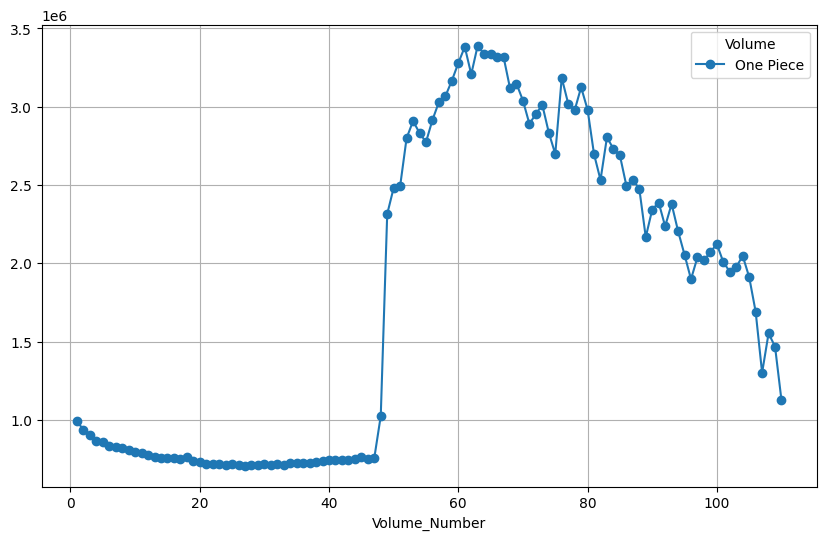

In [13]:
filter_series = ['One Piece']
filtered_table_volumes= table_volumes[table_volumes['Volume'].isin(filter_series)]


df_pivot = filtered_table_volumes.pivot_table(index='Volume_Number', columns='Volume', values='Sales', aggfunc='sum')
ax = df_pivot.plot(kind='line', marker='o', figsize=(10, 6))

plt.grid(True)
plt.show()

Ok we have a problem. This dataset is all the volume sold in a specifical year, so if i want to get only the new volume I need to do some works. 
Now i get the year for every volume.

In [14]:
url = "https://en.wikipedia.org/w/index.php?title=List_of_One_Piece_manga_volumes&oldid=1308849256"

headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

tables = soup.find_all('table', class_='wikitable')
volume_year = {}

for table in tables:
    rows = table.find_all('tr')
    for row in rows[1:]:  # Skip header
        cols = row.find_all(['td', 'th'])
        if len(cols) >= 3:
            volume_text = cols[0].get_text(strip=True)
            volume_match = re.search(r'(\d+)', volume_text)
            if volume_match:
                volume_num = int(volume_match.group(1))
                for col in cols[1:4]:
                    text = col.get_text(strip=True)
                    year_match = re.search(r'(19\d{2}|20\d{2})', text)
                    if year_match:
                        year = int(year_match.group(1))
                        volume_year[volume_num] = year
                        break
volume_years = pd.DataFrame(list(volume_year.items()), columns=['Volume_Number', 'Year'])

print(volume_years)

     Volume_Number  Year
0                1  1997
1                2  1998
2                3  1998
3                4  1998
4                5  1998
..             ...   ...
109            110  2024
110            111  2025
111            112  2025
112            113  2025
113            114  2026

[114 rows x 2 columns]


So now I filter the data for only having the volume which were publish in the year of the data.

In [15]:
filter_series = ['One Piece']
filtered_table_volumes= table_volumes[table_volumes['Volume'].isin(filter_series)]

df_filtrato = pd.merge(filtered_table_volumes, volume_years, on=['Volume_Number', 'Year'], how='inner')

print(df_filtrato.head())


   Ranking          Title    Sales  Year     Volume  Volume_Number
0        1  One Piece #50  1678208  2008  One Piece          50.00
1        2  One Piece #51  1646978  2008  One Piece          51.00
2        4  One Piece #49  1544000  2008  One Piece          49.00
3      101  One Piece #53  2057528  2009  One Piece          53.00
4      102  One Piece #54  1963696  2009  One Piece          54.00


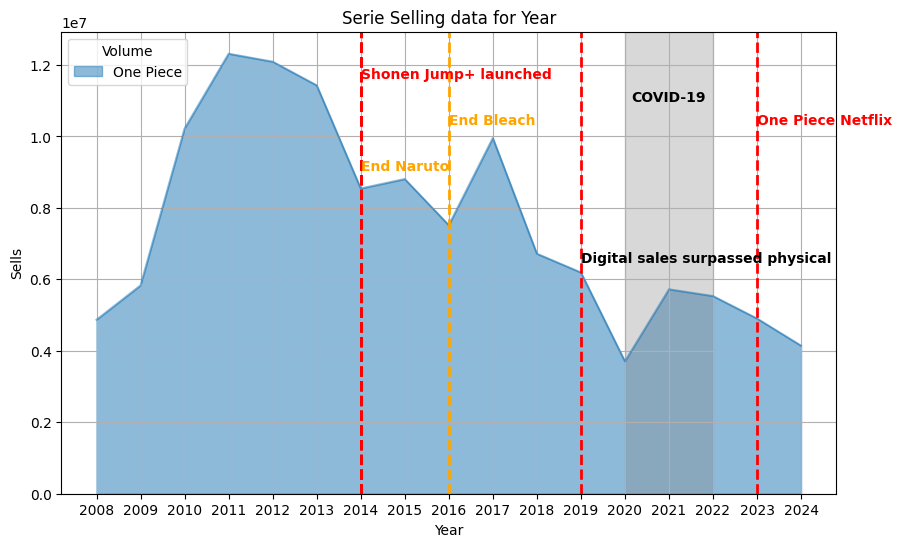

In [16]:
df_pivot = df_filtrato.pivot_table(index='Year', columns='Volume', values='Sales', aggfunc='sum')

ax = df_pivot.plot(kind='area', alpha=0.5, figsize=(10, 6))
years = df_pivot.index.unique()
plt.xticks(np.arange(min(years), max(years) + 1, 1))

plt.title('Serie Selling data for Year')
plt.xlabel('Year')
plt.ylabel('Sells')
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)


# Marker for Shonen Jump+
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)
plt.text(2014, ax.get_ylim()[1]*0.9, 'Shonen Jump+ launched', color='red', fontweight='bold')

# Marker for Bleach
plt.axvline(x=2016, color='orange', linestyle='--', linewidth=2)
plt.text(2016, ax.get_ylim()[1]*0.8, 'End Bleach', color='orange', fontweight='bold')

# Marker for Naruto
plt.axvline(x=2014, color='red', linestyle='--', linewidth=2)
plt.text(2014, ax.get_ylim()[1]*0.7, 'End Naruto', color='orange', fontweight='bold')

# Marker for digital manga sales have surpassed physical manga  source: https://hon.jp/news/1.0/0/30684
plt.axvline(x=2019, color='red', linestyle='--', linewidth=2)
plt.text(2019, ax.get_ylim()[1]*0.5, 'Digital sales surpassed physical', color='black', fontweight='bold')

# Marker for One Piece Netflix
plt.axvline(x=2023, color='red', linestyle='--', linewidth=2)
plt.text(2023, ax.get_ylim()[1]*0.8, 'One Piece Netflix', color='red', fontweight='bold')

# Gray area for the COVID-19 years with label
plt.axvspan(2020, 2022, color='gray', alpha=0.3)
plt.text(2021, ax.get_ylim()[1]*0.85, 'COVID-19', color='black', fontweight='bold', ha='center')

plt.grid(True)
plt.show()